# High-level evaluation and journal figures

Forecasting, calibration, extreme events, retrieval, imputation, transfer, continual learning, uncertainty, significance, and efficiency are evaluated on the chronological test period.

In [1]:
from pathlib import Path
import json, sys
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from pmwm.common import load_config
config = load_config(ROOT / 'config.yaml')
print(f"Project root: {ROOT}")

Project root: /home/urad/S


In [2]:
from pmwm.evaluation import run_evaluation
from pmwm.plots import generate_figures
run_evaluation(config)
generate_figures(config)

PosixPath('/home/urad/S/results/figure_manifest.csv')

In [3]:
import pandas as pd
leaderboard = pd.read_csv(ROOT / 'results/tables/leaderboard.csv')
display(leaderboard)

,model,rmse_z,mae_z,acc,skill_vs_climatology,skill_vs_persistence,crps_z
0,PMWM (full),0.910381,0.649897,0.586687,0.352296,0.524239,0.459176
1,PMWM (no event slots),0.910960,0.641443,0.588619,0.351472,0.523633,0.456019
2,PMWM (reservoir),0.916375,0.651018,0.581206,0.343739,0.517953,0.461782
3,Neural backbone,0.918724,0.653701,0.579315,0.340370,0.515478,0.462855
4,Analog memory,0.957514,0.713017,0.531808,0.283493,0.473701,NaN
5,Ridge-AR,0.959460,0.699596,0.520692,0.280578,0.471559,NaN
6,Seasonal climatology,1.131188,0.868993,NaN,0.000000,0.265465,NaN
7,Persistence,1.319862,0.902011,0.375721,-0.361406,0.000000,NaN


In [4]:
summary = json.loads((ROOT / 'results/summary.json').read_text())
summary

{'best_model': 'PMWM (full)',
 'test_samples_seen': 78804,
 'test_samples_held_out': 26268,
 'ridge_alpha': 0.1,
 'pmwm_rmse_z': 0.9103806182277324,
 'backbone_rmse_z': 0.9187243010371627,
 'relative_rmse_improvement_over_backbone_percent': 0.9081813553871385,
 'pmwm_acc': 0.5866870557074642,
 'pmwm_crps_z': 0.45917612314224243,
 'coverage_90': 0.8970626491041064,
 'event_auroc': 0.8655463993128638,
 'event_auprc': 0.3262014357665571,
 'retrieval_ndcg_at_k': 0.6959355528211842,
 'bootstrap_mse_reduction_ci': [0.014439582033082843, 0.016203710716217755],
 'backward_transfer': -0.0010001110961547766}

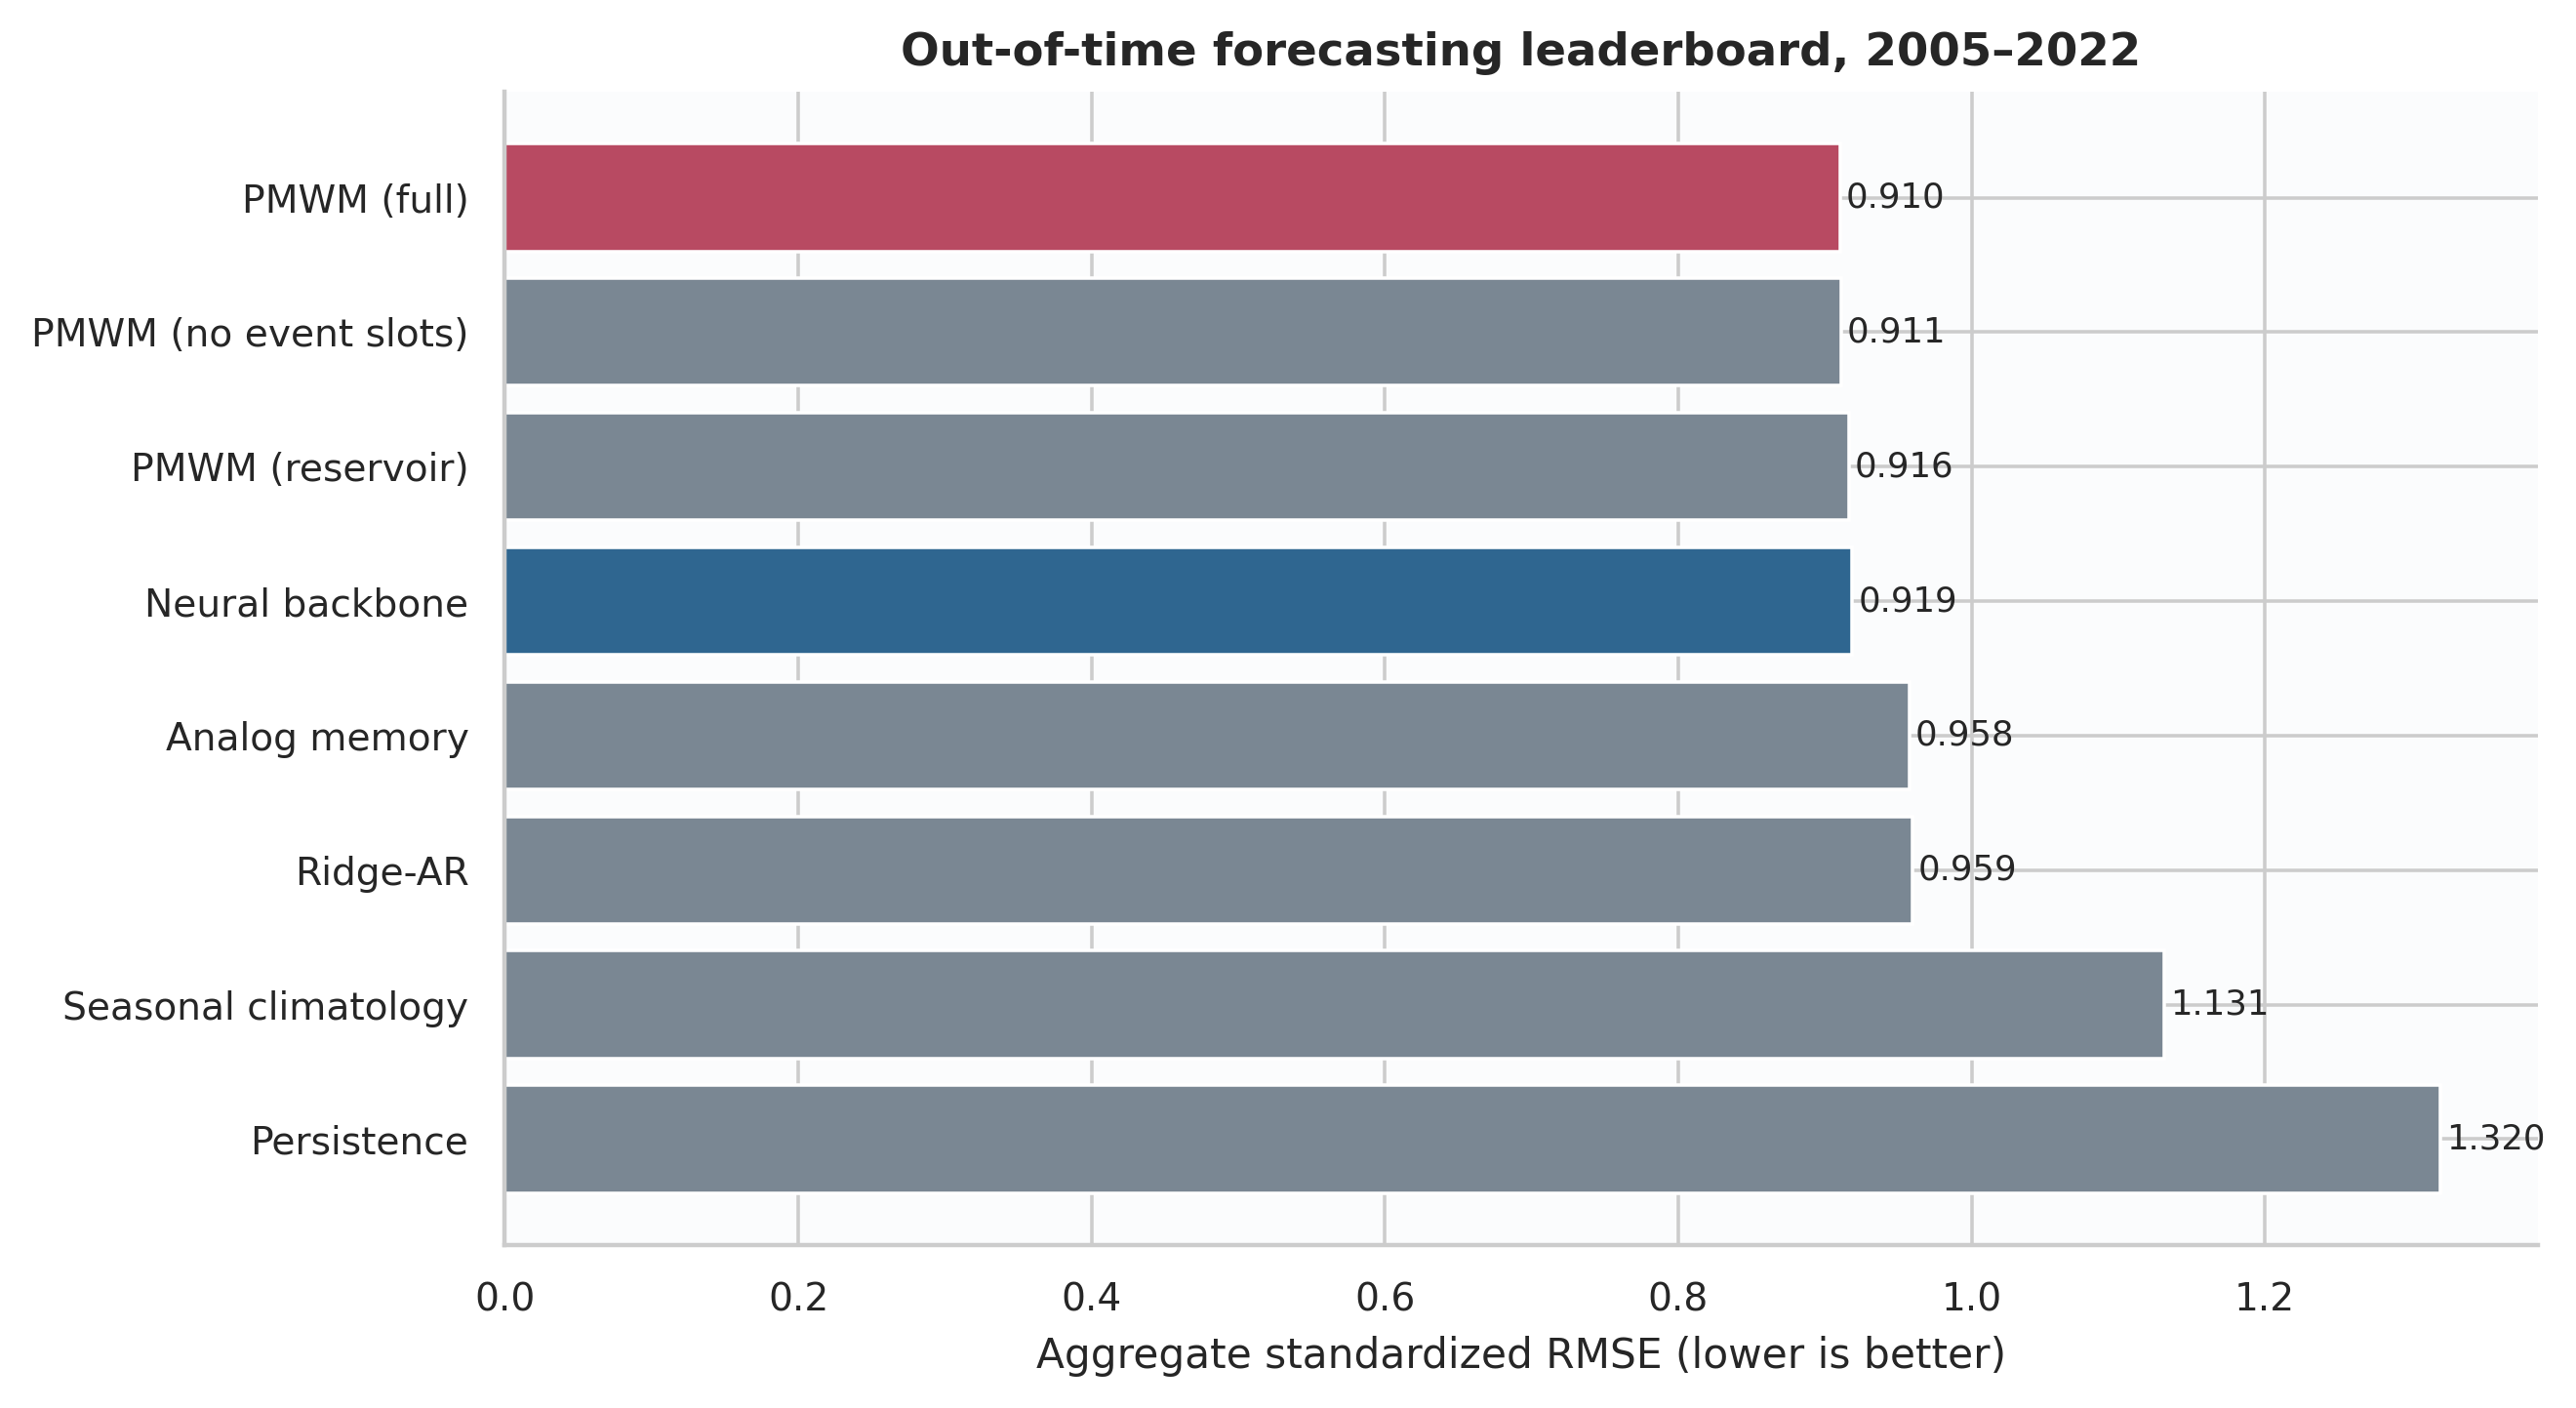

In [5]:
from IPython.display import Image, display
display(Image(filename=ROOT / 'figures/png/fig07_forecast_leaderboard.png', width=850))